In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from datetime import datetime, date
import plotly.graph_objects as go
import numpy as np

from config import (
    CUSTOMERS_PATH,
    MERCHANTS_PATH
)

from generate_customers import (
    AGE_GROUPS
)

In [2]:
customers = pd.read_csv(CUSTOMERS_PATH)

## Calculation of age 
## As the excersice is ment to be realized for 2026-01-01 then
def age(date_of_birth):
    born = pd.to_datetime(date_of_birth)
    today = pd.to_datetime('2026-01-01')
    return today.year - born.year - ((today.month, today.day) < (born.month, born.day))

customers['age'] = customers['date_of_birth'].apply(age)
customers['is_foreign'] = customers['nationality'] != 'Spain'


bins = [18, 25, 35, 45, 55, 65, 75, np.inf]
customers["age_group"] = pd.cut(
    customers["age"], bins=bins, labels=AGE_GROUPS, right=False
)

customers.head(5)

,customer_id,date_of_birth,nationality,country_of_residence,occupation,employment_status,customer_since,age,is_foreign,age_group
0,ID_C00001,1952-05-06,Spain,Spain,Retired,Retired,2018-10-14,73,False,65-74
1,ID_C00002,1973-01-06,Spain,Spain,Sales representative,Employed,2022-08-28,52,False,45-54
2,ID_C00003,1955-01-27,Spain,Spain,Retired,Retired,2024-06-06,70,False,65-74
3,ID_C00004,1962-12-05,Spain,Spain,Construction worker,Employed,2022-10-19,63,False,55-64
4,ID_C00005,1999-08-09,Spain,Spain,Manufacturing worker,Self-employed,2023-05-06,26,False,25-34


In [3]:
## Quick Data Exploration 

# 1. Foreigner vs. Native Ratio
print("--- FOREIGNER PROPORTION ---")
print((customers["is_foreign"].value_counts(normalize=True) * 100).round(2))

# 2. Age Group Distribution
print("\n--- AGE GROUP PROPORTION ---")
print((customers["age_group"].value_counts(normalize=True) * 100).round(2))

# 3. Employment Status Distribution
print("\n--- EMPLOYMENT STATUS PROPORTION ---")
print(
    (customers["employment_status"].value_counts(normalize=True) * 100).round(2)
)

# 4. Nationality Distribution
print("\n--- NATIONALITY PROPORTION ---")
print((customers["nationality"].value_counts(normalize=True) * 100).round(2))

# 5. Top Occupations
print("\n--- TOP 10 OCCUPATIONS ---")
print(
    (customers["occupation"].value_counts(normalize=True).head(10) * 100).round(
        2
    )
)


--- FOREIGNER PROPORTION ---
is_foreign
False    84.8
True     15.2
Name: proportion, dtype: float64

--- AGE GROUP PROPORTION ---
age_group
45-54    18.4
55-64    18.0
25-34    17.0
35-44    14.6
65-74    14.2
75+      10.6
18-24     7.2
Name: proportion, dtype: float64

--- EMPLOYMENT STATUS PROPORTION ---
employment_status
Employed         48.0
Retired          19.4
Unemployed       10.2
Self-employed     9.6
Other             9.2
Student           3.6
Name: proportion, dtype: float64

--- NATIONALITY PROPORTION ---
nationality
Spain             84.8
Morocco            3.2
Romania            2.6
United Kingdom     1.4
Venezuela          0.8
China              0.8
Colombia           0.8
Italy              0.8
Pakistan           0.8
France             0.6
Argentina          0.4
Ecuador            0.4
Brazil             0.4
Portugal           0.4
Germany            0.4
Peru               0.4
Honduras           0.4
Russia             0.2
Ukraine            0.2
Bulgaria           0.2
Nam

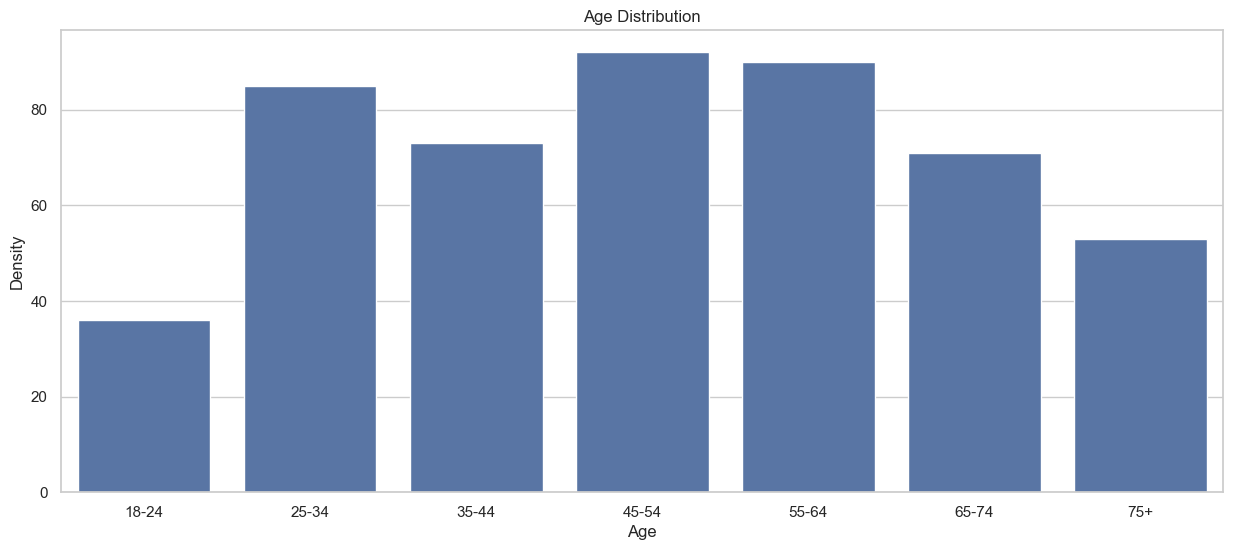

In [4]:
sns.set_theme(style="whitegrid")
f, ax = plt.subplots(figsize=(15, 6))

sns.set_color_codes("pastel")
sns.countplot(
    customers,
    x="age_group",
    # hue="is_foreign"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

In [5]:


# 1. Agrupar y contar las frecuencias entre age_group y employment_status
sankey_data = (
    customers.groupby(["age_group", "employment_status"])
    .size()
    .reset_index(name="count")
)

# 2. Crear una lista con todos los nodos únicos (fuente y destino)
all_nodes = list(
    np.unique(
        sankey_data["age_group"].tolist()
        + sankey_data["employment_status"].tolist()
    )
)

# 3. Mapear los nombres de los nodos a índices numéricos
node_indices = {node: idx for idx, node in enumerate(all_nodes)}

sankey_data["source"] = sankey_data["age_group"].map(node_indices)
sankey_data["target"] = sankey_data["employment_status"].map(node_indices)

# 4. Construir la figura del Sankey
fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                pad=15,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=all_nodes,
                color="skyblue",
            ),
            link=dict(
                source=sankey_data["source"],
                target=sankey_data["target"],
                value=sankey_data["count"],
            ),
        )
    ]
)

fig.update_layout(
    title_text="Flow from Age Group to Employment Status", font_size=12
)
fig.show()

C:\Users\Ana\AppData\Local\Temp\ipykernel_27552\3815934668.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customers.groupby(["age_group", "employment_status"])


In [7]:
merchants = pd.read_csv(MERCHANTS_PATH)

merchants.head(5)

,merchant_id,merchant_category,country,city
0,M0001,Utilities,Spain,Alicante
1,M0002,Travel,Spain,Barcelona
2,M0003,Education,Spain,Palma
3,M0004,Clothing,Spain,Madrid
4,M0005,Grocery,Spain,Zaragoza


In [8]:
## Quick Data Exploration 

# 1. Total Count & Unique Merchants
print("--- SUMMARY ---")
print(f"Total Merchants: {len(merchants)}")
print(f"Unique Merchant IDs: {merchants['merchant_id'].nunique()}")

# 2. Merchant Categories Breakdown
print("\n--- MERCHANT CATEGORY PROPORTION ---")
print(
    (merchants["merchant_category"].value_counts(normalize=True) * 100).round(2)
)

# 3. City Breakdown (Top 10)
print("\n--- TOP 10 CITIES ---")
print((merchants["city"].value_counts(normalize=True).head(10) * 100).round(2))

# 4. Country Distribution
print("\n--- COUNTRY PROPORTION ---")
print((merchants["country"].value_counts(normalize=True) * 100).round(2))

--- SUMMARY ---
Total Merchants: 250
Unique Merchant IDs: 250

--- MERCHANT CATEGORY PROPORTION ---
merchant_category
Grocery            17.6
Restaurants        12.4
Clothing            9.2
Transport           8.8
Utilities           8.0
Electronics         8.0
Entertainment       7.6
Travel              7.2
Healthcare          5.2
Education           4.4
Online Services     4.4
Hotels              3.6
Jewellery           2.0
Luxury Goods        1.6
Name: proportion, dtype: float64

--- TOP 10 CITIES ---
city
Madrid       21.6
Barcelona    13.2
Málaga        8.0
Seville       7.2
Valencia      6.8
Zaragoza      6.0
Bilbao        4.4
Palma         4.0
Murcia        4.0
Alicante      3.2
Name: proportion, dtype: float64

--- COUNTRY PROPORTION ---
country
Spain                   91.6
France                   2.0
Italy                    1.2
United Arab Emirates     1.2
United States            1.2
Germany                  1.2
United Kingdom           0.8
Portugal                 0.4
Mexi